# Self Organising Digital Circuits

## Imports

In [194]:
import copy
import os

import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import PIL.ImageDraw
import PIL.ImageFont
from tqdm.auto import trange

# pl.style.use("dark_background")


def np2pil(a):
    a = np.asarray(a)
    if a.dtype.kind == "f":
        a = np.uint8(a.clip(0, 1) * 255)

    return PIL.Image.fromarray(a)


def imshow(a):
    display(np2pil(a))


def zoom(a, k=2):
    return np.repeat(np.repeat(a, k, 1), k, 0)


def tile2d(a, w=None):
    a = np.asarray(a)
    if w is None:
        w = int(np.ceil(np.sqrt(len(a))))
    th, tw = a.shape[1:3]
    pad = (w - len(a)) % w
    a = np.pad(a, [(0, pad)] + [(0, 0)] * (a.ndim - 1), "constant")
    h = len(a) // w
    a = a.reshape([h, w] + list(a.shape[1:]))
    a = np.rollaxis(a, 2, 1).reshape([th * h, tw * w] + list(a.shape[4:]))
    return a

In [195]:
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_PLATFORM_NAME"] = "cpu"

os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [196]:
import jax
import jax.numpy as jp
import jraph
import optax
from flax import nnx

print(jax.devices())


[CpuDevice(id=0)]


In [197]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [198]:
import logging

# Configure logging
log = logging.getLogger(__name__)
from boolean_nca_cc.training.checkpointing import configure_notebook_logging

# Enable logging in the notebook
configure_notebook_logging()

Logging configured for notebooks. Level: INFO


## Load Model

First thing to do is to load the model / config

In [199]:
from boolean_nca_cc.circuits.model import generate_layer_sizes
from boolean_nca_cc.circuits.tasks import get_task_data
from boolean_nca_cc.circuits.viz import plot_wandb_stepwise_results
from boolean_nca_cc.training.checkpointing import (
    load_config_from_wandb,
    load_model_from_config_and_checkpoint,
)
from boolean_nca_cc.training.evaluation import (
    evaluate_model_stepwise_batched,
    get_fraction_damaged_gates,
)
from boolean_nca_cc.training.pool.pool import initialize_graph_pool
from boolean_nca_cc.training.pool.structural_perturbation import compute_damage_params


In [200]:
# run_id = "gbena/boolean-nca-cc/xdxlabd2" # Fixed wires, damages, reverse task
run_id = "gbena/boolean-nca-cc/f1vzpb58"  # Random wires, damages, reverse task

loaded_config, checkpoint_path, run_id = load_config_from_wandb(
    run_id=run_id.split("/")[-1],
    entity="gbena",
    filename="best_model_eval_damaged_out_test_hard_accuracy",
    use_cache=False,
    # filename="latest_checkpoint",
)


2026-02-10 20:56:31,330 - boolean_nca_cc.training.checkpointing - INFO - Looking for run with ID: f1vzpb58


KeyboardInterrupt: 

## Create pool

In [ ]:
case_n = 2**loaded_config.circuit.input_bits
base_key = jax.random.PRNGKey(loaded_config.seed)
eval_key = jax.random.fold_in(base_key, 1)
hidden_dim = loaded_config.circuit.circuit_hidden_dim
n_message_steps = loaded_config.training.n_message_steps
input_n, output_n = loaded_config.circuit.input_bits, loaded_config.circuit.output_bits
arity = loaded_config.circuit.arity
layer_n = loaded_config.circuit.num_layers

layer_sizes = generate_layer_sizes(
    input_n, output_n, arity, layer_n=layer_n, width_factor=loaded_config.circuit.width_factor
)
n_gates = sum(group_n for group_n, _ in layer_sizes)

print(f"n_gates: {n_gates}")

if loaded_config.training.wiring_mode == "fixed":
    pool_key = eval_key
else:
    pool_key = jax.random.fold_in(eval_key, 1)

wires_key, logits_key = jax.random.split(pool_key, 2)

batch_size = 32

pool = initialize_graph_pool(
    wires_key=wires_key,
    logits_key=logits_key,
    pool_size=batch_size,
    layer_sizes=layer_sizes,
    arity=arity,
    input_n=input_n,
    circuit_hidden_dim=hidden_dim,
    wiring_mode=loaded_config.training.wiring_mode,
    # noise_scale=loaded_config.pool.noise_scale,
    noise_scale=0.0,
)

print(f"Pool of size {batch_size} initialised ! Circuits are: {pool.graphs.n_node[0]} nodes")


n_gates: 264
Pool of size 32 initialised ! Circuits are: [264] nodes


## Get Data

In [ ]:
(x_train, y_train), (x_test, y_test), (x, y0) = get_task_data(
    loaded_config.circuit.task,
    case_n,
    input_bits=loaded_config.circuit.input_bits,
    output_bits=loaded_config.circuit.output_bits,
    text=loaded_config.circuit.text,
    # text="!NCA Circuits!",
    # text="Hello!",
    train_test_split=True,
    test_ratio=0.2,
    seed=eval_key,
)

damage_params = compute_damage_params(loaded_config, layer_sizes, None)
n_damage_steps = 2
n_steps = 256
damage_steps = jp.linspace(0, n_steps, n_damage_steps + 1, endpoint=False).astype(int)[1:]
print(f"Damage steps: {damage_steps}")

damage_modes = ["none", "probabilistic", "deterministic"]
permanent_modes = [False, True]


Damage steps: [ 85 170]


## Backprop training

In [ ]:
from types import SimpleNamespace

from boolean_nca_cc.circuits.train import LossConfig, loss_f
from boolean_nca_cc.training.pool.structural_perturbation import (
    apply_probabilistic_gate_failure,
    create_eligible_gate_mask,
    create_flat_knockout_pattern,
    flat_to_layered_mask,
    layered_to_flat_mask,
)


def _logits_to_flat_nodes(logits_list, input_n, arity):
    logit_dim = 2**arity
    parts = [jp.zeros((input_n, logit_dim))]
    for l in logits_list:
        gn, gs, ls = l.shape
        parts.append(l.reshape(gn * gs, ls))
    return jp.concatenate(parts, axis=0)


def run_bp_baseline_vmapped(
    opt,
    pool,
    x_data,
    y_data,
    n_steps,
    layer_sizes,
    input_n,
    arity,
    loss_cfg,
    damage_mode="none",
    permanent=False,
    damage_steps=None,
    knockouts_per_event=0,
    p_fault=None,
    p_fault_onset_step=0,
    faulty_value=-10.0,
    key=jax.random.PRNGKey(42),
    verbose=True,
    x_test=None,
    y_test=None,
):
    """
    Vmapped BP baseline — all circuits optimized in parallel.
    Same output format as evaluate_model_stepwise_batched.
    """
    if isinstance(loss_cfg, dict):
        loss_cfg = LossConfig.from_dict(loss_cfg)

    batch_size = pool.wires[0].shape[0]
    total_gates = sum(n for n, _ in layer_sizes)
    input_gates = layer_sizes[0][0]
    output_gates = layer_sizes[-1][0]
    eligible_start = input_gates
    eligible_end = total_gates - output_gates
    eligible_flat = create_eligible_gate_mask(layer_sizes)
    damage_steps_set = set(int(s) for s in damage_steps) if damage_steps is not None else set()

    eval_x = x_test if x_test is not None else x_data
    eval_y = y_test if y_test is not None else y_data

    # --- Batched initial state ---
    batch_params = pool.logits  # list of (batch, gn, gs, lut)
    batch_wires = pool.wires  # list of (batch, ...)
    batch_opt_state = jax.vmap(opt.init)(batch_params)
    batch_gate_mask = jp.ones((batch_size, total_gates), dtype=jp.float32)

    # Pre-generate all per-circuit-per-step keys
    all_keys = jax.random.split(key, n_steps * batch_size).reshape(n_steps, batch_size, -1)

    # ----------------------------------------------------------------
    # Single-circuit functions (will be vmapped)
    # ----------------------------------------------------------------
    def _preserve(new_params, old_params, gate_mask_flat):
        """Restore knocked-out gate params after optimizer update."""
        idx = input_gates
        preserved = []
        for new_l, old_l in zip(new_params, old_params):
            gn, gs, ls = new_l.shape
            n = gn * gs
            m = gate_mask_flat[idx : idx + n].reshape(gn, gs, 1)
            preserved.append(jp.where(m == 0.0, old_l, new_l))
            idx += n
        return preserved

    def grad_step(params, wires, opt_state, gmask):
        gml = flat_to_layered_mask(gmask, layer_sizes)
        (_, _), grad = jax.value_and_grad(
            lambda p: loss_f(p, wires, x_data, y_data, loss_cfg=loss_cfg, gate_mask=gml),
            has_aux=True,
        )(params)
        upd, new_os = opt.update(grad, opt_state, params)
        new_p = optax.apply_updates(params, upd)
        new_p = _preserve(new_p, params, gmask)
        return new_p, new_os

    def evaluate(params, wires, gmask):
        gml = flat_to_layered_mask(gmask, layer_sizes)
        loss, aux = loss_f(params, wires, eval_x, eval_y, loss_cfg=loss_cfg, gate_mask=gml)
        return loss, aux["hard_loss"], aux["accuracy"], aux["hard_accuracy"]

    def record_logits(params):
        return _logits_to_flat_nodes(params, input_n, arity)

    def det_damage(params, gmask, k):
        ko = create_flat_knockout_pattern(
            k, total_gates, eligible_start, eligible_end, knockouts_per_event
        )
        idx = input_gates
        new_p = []
        for ll in params:
            gn, gs, ls = ll.shape
            m = ko[idx : idx + gn * gs].reshape(gn, gs, 1)
            new_p.append(jp.where(m == 0.0, faulty_value, ll))
            idx += gn * gs
        new_mask = gmask * ko if permanent else gmask
        return new_p, new_mask

    def prob_damage(params, gmask, k):
        ld = params[0].shape[-1]
        parts = [jp.zeros((input_n, ld))]
        for l in params:
            gn, gs, ls = l.shape
            parts.append(l.reshape(gn * gs, ls))
        full = jp.concatenate(parts)
        m_in = gmask if permanent else jp.ones_like(gmask)
        new_full, new_m = apply_probabilistic_gate_failure(
            k, full, m_in, eligible_flat, p_fault, faulty_value
        )
        final_m = new_m if permanent else gmask
        idx = input_n
        new_p = []
        for ll in params:
            gn, gs, ls = ll.shape
            n = gn * gs
            new_p.append(new_full[idx : idx + n].reshape(gn, gs, ls))
            idx += n
        return new_p, final_m

    # ----------------------------------------------------------------
    # JIT-compiled vmapped versions
    # ----------------------------------------------------------------
    v_grad = jax.jit(jax.vmap(grad_step))
    v_eval = jax.jit(jax.vmap(evaluate))
    v_record = jax.jit(jax.vmap(record_logits))
    v_det_dmg = jax.jit(jax.vmap(det_damage))
    v_prob_dmg = jax.jit(jax.vmap(prob_damage))

    # ----------------------------------------------------------------
    # Main loop (Python loop over steps, vmapped over batch)
    # ----------------------------------------------------------------
    all_logits = []
    losses, hard_losses, accuracies, hard_accuracies = [], [], [], []

    iterator = trange(n_steps, desc="BP (vmapped)") if verbose else range(n_steps)
    for step in iterator:
        step_keys = all_keys[step]  # (batch, 2)

        # --- Damage ---
        if damage_mode == "deterministic" and step in damage_steps_set:
            batch_params, batch_gate_mask = v_det_dmg(batch_params, batch_gate_mask, step_keys)
        elif damage_mode == "probabilistic" and p_fault is not None and step >= p_fault_onset_step:
            batch_params, batch_gate_mask = v_prob_dmg(batch_params, batch_gate_mask, step_keys)

        # --- Gradient step ---
        batch_params, batch_opt_state = v_grad(
            batch_params, batch_wires, batch_opt_state, batch_gate_mask
        )

        # --- Eval & record ---
        sl, shl, sa, sha = v_eval(batch_params, batch_wires, batch_gate_mask)
        losses.append(float(jp.mean(sl)))
        hard_losses.append(float(jp.mean(shl)))
        accuracies.append(float(jp.mean(sa)))
        hard_accuracies.append(float(jp.mean(sha)))
        all_logits.append(v_record(batch_params))

    # (steps, batch, nodes, logit_dim) → (batch, steps, nodes, logit_dim)
    batch_logits = jp.stack(all_logits).transpose(1, 0, 2, 3)

    step_metrics = {
        "step": list(range(1, n_steps + 1)),
        "loss": losses,
        "hard_loss": hard_losses,
        "accuracy": accuracies,
        "hard_accuracy": hard_accuracies,
        "soft_accuracy": accuracies,
        "soft_loss": losses,
        "graphs": SimpleNamespace(nodes={"logits": batch_logits}),
        "all_metrics": {
            "loss": losses,
            "hard_loss": hard_losses,
            "accuracy": accuracies,
            "hard_accuracy": hard_accuracies,
        },
    }

    if verbose:
        print(
            f"Final: Loss={losses[-1]:.4f}, Acc={accuracies[-1]:.4f}, "
            f"Hard Acc={hard_accuracies[-1]:.4f}"
        )

    return None, step_metrics


bp_eval_results = None

In [ ]:
opt = optax.adamw(1, 0.8, 0.8, weight_decay=1e-1)

bp_eval_results = {
    (damage_mode, permanent): run_bp_baseline_vmapped(
        opt=opt,
        pool=pool,
        x_data=x_train,
        y_data=y_train,
        x_test=x_test,
        y_test=y_test,
        n_steps=n_steps,
        layer_sizes=layer_sizes,
        input_n=input_n,
        arity=arity,
        loss_cfg=LossConfig(loaded_config.loss),
        p_fault=damage_params["p_fault_eval"] if damage_mode == "probabilistic" else None,
        p_fault_onset_step=0,
        damage_mode=damage_mode,
        damage_steps=damage_steps,
        knockouts_per_event=damage_params["knockouts_per_event"],
    )
    for damage_mode in damage_modes
    for permanent in permanent_modes
    if not (damage_mode == "none" and permanent)
}

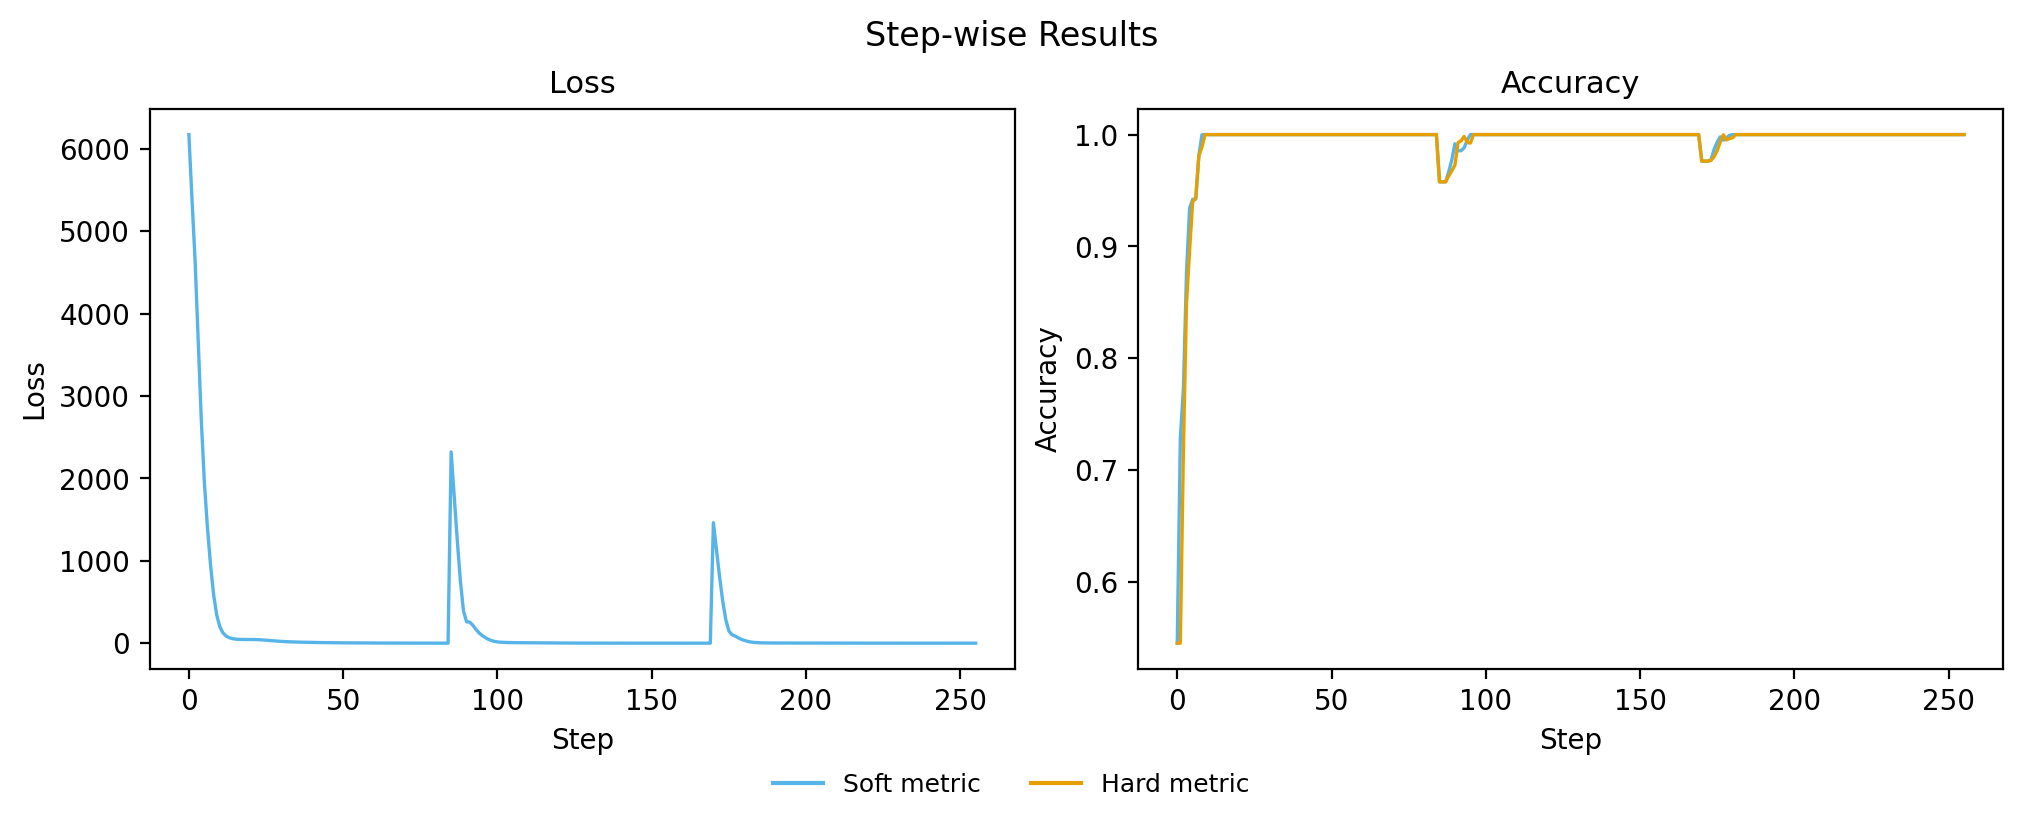

In [ ]:
plot_wandb_stepwise_results(bp_eval_results[("deterministic", True)][1])
plt.show()


## Load Model

In [ ]:
# Load model from config and checkpoint
best_attn_model, loaded_dict, init_attn_model = load_model_from_config_and_checkpoint(
    config=loaded_config,
    checkpoint_path=checkpoint_path,
    run_id=run_id,
    seed=loaded_config.seed,
    n_node=int(pool.graphs.n_node[0].item()),
)


2026-02-10 19:56:25,090 - boolean_nca_cc.training.checkpointing - INFO - Loading model from saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-10 19:56:25,090 - boolean_nca_cc.training.checkpointing - INFO - Loading checkpoint with compatibility handling: saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-10 19:56:25,097 - boolean_nca_cc.training.checkpointing - INFO - Successfully loaded checkpoint with working compatibility loader
2026-02-10 19:56:25,097 - boolean_nca_cc.training.checkpointing - INFO - Converted compatible objects to nnx format


Instantiating model using config: boolean_nca_cc.models.CircuitGatheredAttention
Instantiate overrides: {'arity': 4, 'rngs': Rngs( # RngState: 2 (12 B)
  params=RngStream( # RngState: 2 (12 B)
    tag='params',
    key=RngKey( # 1 (8 B)
      value=Array((), dtype=key<fry>) overlaying:
      [0 0],
      tag='params'
    ),
    count=RngCount( # 1 (4 B)
      value=Array(0, dtype=uint32),
      tag='params'
    )
  )
), 'n_node': 264}
Successfully instantiated model: CircuitGatheredAttention


In [ ]:
damage_modes = ["none", "probabilistic", "deterministic"]
permanents = [False, True]

attn_eval_results = {
    (damage_mode, permanent): evaluate_model_stepwise_batched(
        model=best_attn_model,
        batch_wires=pool.wires,
        batch_logits=pool.logits,
        x_data=x_test,
        y_data=y_test,
        input_n=input_n,
        n_message_steps=1024,
        arity=arity,
        circuit_hidden_dim=hidden_dim,
        loss_cfg=LossConfig(dict(loaded_config.loss)),
        layer_sizes=layer_sizes,
        damage_steps=damage_steps if damage_mode == "deterministic" else None,
        knockout_per_damage_step=damage_params["knockouts_per_event"]
        if damage_mode == "deterministic"
        else None,
        p_fault=damage_params["p_fault_eval"] if damage_mode == "probabilistic" else None,
        bidirectional_edges=True,
        permanent_damage=permanent,
        verbose=True,
        # No-repair baseline
        compute_no_repair_baseline=False,
        p_fault_onset_step=0,
    )
    for damage_mode in damage_modes
    for permanent in permanents
    if not (damage_mode == "none" and permanent)
}


Evaluation complete: 1024 steps
  Loss: 7411.6201
  Accuracy: 0.8272
  Hard Acc: 0.8271
Evaluation complete: 1024 steps
  Loss: 7418.5786
  Accuracy: 0.8286
  Hard Acc: 0.8284
Evaluation complete: 1024 steps
  Loss: 13123.9883
  Accuracy: 0.6792
  Hard Acc: 0.6789
Evaluation complete: 1024 steps
  Loss: 7468.9238
  Accuracy: 0.8274
  Hard Acc: 0.8273
Evaluation complete: 1024 steps
  Loss: 7064.2793
  Accuracy: 0.7926
  Hard Acc: 0.7923


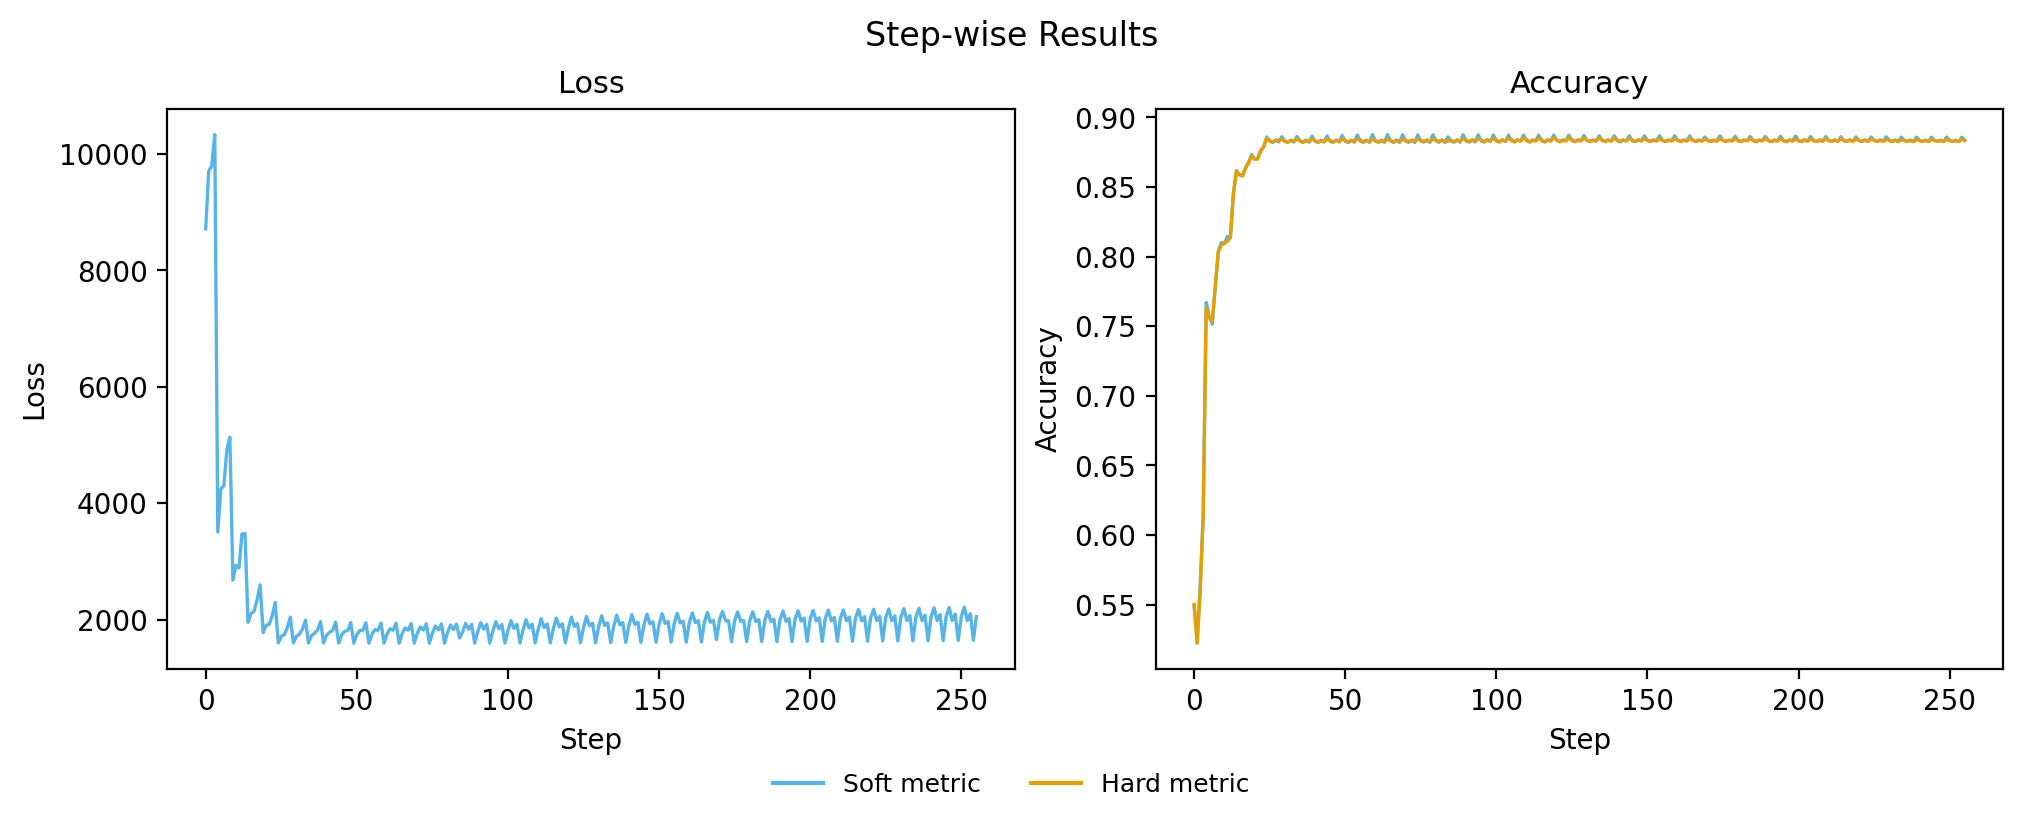

In [ ]:
plot_wandb_stepwise_results(attn_eval_results[("deterministic", False)][1])
plt.show()


## PCA

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from umap import UMAP

# =====================================================================
# Build a single DataFrame with ALL trajectories + metadata
# =====================================================================


def build_trajectory_df(eval_results: dict, bp_results: dict | None = None) -> pd.DataFrame:
    """
    Build a tidy DataFrame from eval_results dict.

    eval_results: dict mapping (damage_mode, permanent) -> (final_graphs, step_metrics)

    Returns DataFrame with columns:
        batch, step, damage_mode, permanent, loss, hard_accuracy, + one col per logit feature
    """
    records = []

    for (damage_mode, permanent), (_, step_metrics) in tqdm(
        eval_results.items(),
        total=len(eval_results),
        desc="Building trajectory DataFrame from NCA results",
    ):
        logits_traj = np.array(step_metrics["graphs"].nodes["logits"])
        batch_size, n_steps, _, _ = logits_traj.shape

        # Flatten nodes*logits -> single feature vector per (batch, step)
        logits_flat = logits_traj.reshape(batch_size, n_steps, -1)

        # Per-step metrics (batch-averaged)
        # losses = np.array(step_metrics["loss"])  # (n_steps,)
        # hard_accs = np.array(step_metrics["hard_accuracy"])  # (n_steps,)

        for b in range(batch_size):
            for t in range(n_steps):
                records.append(
                    {
                        "batch": b,
                        "step": t,
                        "damage_mode": damage_mode,
                        "permanent": permanent,
                        "logits_vec": logits_flat[b, t],  # np array, will extract later
                        "model": "NCA",
                    }
                )
                records[-1].update(
                    {
                        metric: step_metrics["all_metrics"][metric][b, t].item()
                        for metric in step_metrics["all_metrics"]
                    }
                )

    if bp_results is not None:
        for (damage_mode, permanent), (_, bp_step_metrics) in tqdm(
            bp_results.items(),
            total=len(bp_results),
            desc="Building trajectory DataFrame from BP results",
        ):
            for b in range(batch_size):
                for t in range(n_steps):
                    records.append(
                        {
                            "model": "BP",
                            "batch": b,
                            "step": t,
                            "damage_mode": damage_mode,
                            "permanent": permanent,
                            "logits_vec": bp_step_metrics["graphs"]
                            .nodes["logits"][b, t]
                            .reshape(-1),
                            "loss": bp_step_metrics["loss"][t],
                        }
                    )

    df = pd.DataFrame(records)
    return df


def add_pca_columns(
    df: pd.DataFrame, n_components: int = 2, scale: bool = True, use_sigmoid: bool = True
) -> pd.DataFrame:
    """
    Fit PCA on ALL logit vectors jointly, add PC1/PC2/... columns to df.
    Returns df with new columns + the fitted PCA and scaler objects.
    """
    pca_df = df.copy()
    X = (
        np.stack(pca_df["logits_vec_sigmoid"].values)
        if "logits_vec_sigmoid" in pca_df.columns and use_sigmoid
        else np.stack(pca_df["logits_vec"].values)
    )  # (n_total, feature_dim)

    scaler = StandardScaler() if scale else None
    X_scaled = scaler.fit_transform(X) if scale else X

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    for i in range(n_components):
        pca_df[f"PC{i + 1}"] = X_pca[:, i]

    print(f"PCA on {X.shape[0]} points, feature_dim={X.shape[1]}")
    print(f"Explained variance: {pca.explained_variance_ratio_}")
    print(f"Total explained: {pca.explained_variance_ratio_.sum():.2%}")

    return pca_df, pca, scaler


def add_umap_columns(
    df: pd.DataFrame, n_components: int = 2, scale: bool = True, umap_kwargs: dict = None
):
    """
    Fit UMAP on ALL logit vectors jointly, add UMAP1/UMAP2/... columns to df.

    Key: use PCA pre-reduction + PCA init to preserve trajectory smoothness.
    """
    import umap

    X = np.stack(df["logits_vec"].values)

    scaler = StandardScaler() if scale else None
    X_scaled = scaler.fit_transform(X) if scale else X

    # Step 1: PCA pre-reduction to ~30 dims removes noise,
    # makes UMAP's distance computations much more meaningful
    pca_pre = PCA(n_components=min(30, X_scaled.shape[1]))
    X_pca = pca_pre.fit_transform(X_scaled)
    print(
        f"PCA pre-reduction: {X_scaled.shape[1]} -> {X_pca.shape[1]} dims "
        f"({pca_pre.explained_variance_ratio_.sum():.1%} variance retained)"
    )

    defaults = {
        "n_components": n_components,
        "n_neighbors": 50,  # higher = more global structure preserved
        "min_dist": 0.3,  # higher = less clumping, smoother trajectories
        "metric": "euclidean",
        "init": "spectral",  # spectral init respects global geometry
        "random_state": 42,
    }
    if umap_kwargs:
        defaults.update(umap_kwargs)

    reducer = umap.UMAP(**defaults)
    X_umap = reducer.fit_transform(X_pca)  # fit on PCA-reduced, not raw

    for i in range(n_components):
        df[f"UMAP{i + 1}"] = X_umap[:, i]

    print(f"UMAP on {X_pca.shape[0]} points, input_dim={X_pca.shape[1]}")
    return df, reducer, scaler


In [ ]:
# --- Build it ---
traj_df = build_trajectory_df(attn_eval_results, bp_results=bp_eval_results)

Building trajectory DataFrame from NCA results:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
traj_df["logits_vec_sigmoid"] = traj_df["logits_vec"].apply(lambda x: jax.nn.sigmoid(x))


In [ ]:
models = ["NCA"]


traj_df_pca, pca, scaler = add_pca_columns(
    traj_df.query(f"model in {models}"), n_components=4, use_sigmoid=False
)

# traj_df, umap, scaler = add_umap_columns(traj_df, n_components=4)

# Drop the heavy logits_vec column now that we have PCs
traj_df_pca = traj_df_pca.drop(columns=["logits_vec"])

# Make nice labels
traj_df_pca["damage_label"] = traj_df_pca["damage_mode"].replace(
    {
        "none": "No damage",
        "probabilistic": "Stochastic failures",
        "deterministic": "Shotgun failures",
    }
)


traj_df_pca["permanent_label"] = traj_df_pca["permanent"].map(
    {True: "Permanent", False: "Recoverable"}
)
traj_df_pca["condition"] = traj_df_pca["damage_label"] + "\n" + traj_df_pca["permanent_label"]

print(f"\nDataFrame shape: {traj_df_pca.shape}")
print(f"Conditions: {traj_df_pca.groupby(['damage_mode', 'permanent']).size()}")
traj_df_pca.head()


PCA on 40960 points, feature_dim=4224
Explained variance: [0.39087993 0.04041666 0.02496245 0.02362347]
Total explained: 47.99%

DataFrame shape: (40960, 17)
Conditions: damage_mode    permanent
deterministic  False        8192
               True         8192
none           False        8192
probabilistic  False        8192
               True         8192
dtype: int64


,batch,step,damage_mode,permanent,model,loss,hard_loss,accuracy,hard_accuracy,logits_vec_sigmoid,PC1,PC2,PC3,PC4,damage_label,permanent_label,condition
0,0,0,none,False,NCA,8080.344238,68055.734375,0.568071,0.568274,"[0.00013485111, 0.7964638, 0.22041912, 0.97321...",-98.498978,-6.539437,-3.618454,-2.103892,No damage,Recoverable,No damage\nRecoverable
1,0,1,none,False,NCA,11872.201172,79822.757812,0.486365,0.493386,"[0.0021986521, 0.37384614, 0.03350829, 0.61634...",-91.558823,5.059929,0.411034,-0.149584,No damage,Recoverable,No damage\nRecoverable
2,0,2,none,False,NCA,11588.996094,72159.054688,0.541616,0.542023,"[0.00040725814, 0.9477689, 0.004519923, 0.9870...",-83.342384,-2.175033,-0.672240,-0.017947,No damage,Recoverable,No damage\nRecoverable
3,0,3,none,False,NCA,11938.235352,64592.355469,0.589438,0.589947,"[0.0270431, 0.99592185, 0.00258825, 0.98441905...",-92.337654,-2.027093,-1.046003,-0.111338,No damage,Recoverable,No damage\nRecoverable
4,0,4,none,False,NCA,3929.669434,41065.195312,0.745727,0.739215,"[4.696497e-05, 0.999997, 8.65022e-05, 0.999996...",-75.744293,4.403943,-0.807421,-0.658574,No damage,Recoverable,No damage\nRecoverable


In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# =====================================================================
# Helper: replace seaborn legend with a colorbar
# =====================================================================


def legend_to_colorbar(g, hue_col, data, palette="viridis", label=None, vmin=None, vmax=None):
    """
    Remove seaborn's auto-legend from a FacetGrid/relplot and
    replace it with a single colorbar on the right side.

    Parameters
    ----------
    g : sns.FacetGrid (returned by relplot, FacetGrid, etc.)
    hue_col : str, column name used as hue
    data : DataFrame that was plotted
    palette : str, colormap name
    label : str, colorbar label (defaults to hue_col)
    """
    # Remove the legend seaborn created
    if g.legend is not None:
        g.legend.remove()
    # Also try the _legend attribute (relplot stores it there)
    if hasattr(g, "_legend") and g._legend is not None:
        g._legend.remove()

    vmin = data[hue_col].min() if vmin is None else vmin
    vmax = data[hue_col].max() if vmax is None else vmax

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = cm.ScalarMappable(cmap=palette, norm=norm)
    sm.set_array([])

    # Add colorbar to the figure, stealing space from the right
    g.figure.subplots_adjust(right=0.9)
    cbar_ax = g.figure.add_axes([0.94, 0.2, 0.015, 0.5])  # [left, bottom, width, height]
    cbar = g.figure.colorbar(sm, cax=cbar_ax)
    cbar.set_label(label or hue_col, fontsize=11)

    return g


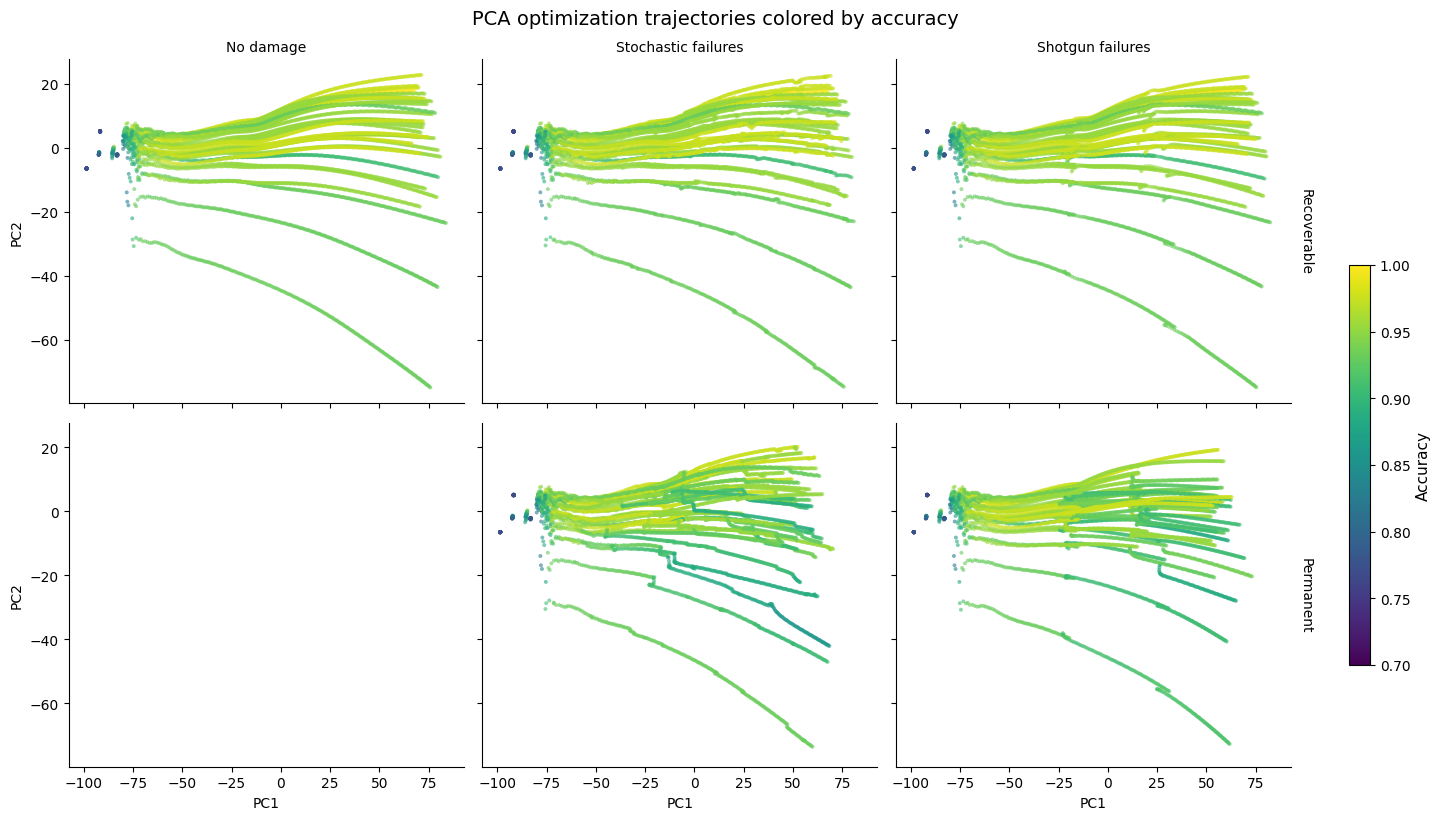

In [ ]:
v_min, v_max = 0.7, 1.0
hue_norm = mcolors.LogNorm(vmin=v_min, vmax=v_max)
hue = "accuracy"

g = sns.relplot(
    data=traj_df_pca,
    x="PC1",
    y="PC2",
    hue=hue,
    style="model",
    col="damage_label",
    row="permanent_label",
    palette="viridis",
    kind="scatter",
    s=8,
    alpha=0.6,
    edgecolor="none",
    facet_kws={"sharex": True, "sharey": True, "margin_titles": True},
    height=4,
    aspect=1.2,
    legend=False,
    hue_norm=hue_norm if hue == "hard_accuracy" else None,
)
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.figure.suptitle("PCA optimization trajectories colored by accuracy", y=1.02, fontsize=14)
legend_to_colorbar(
    g,
    hue,
    traj_df_pca,
    palette="viridis",
    label=hue.replace("_", " ").capitalize(),
    vmin=v_min if "accuracy" in hue else None,
    vmax=v_max if "accuracy" in hue else None,
)

# new_bbox = (bbox.x0, bbox.y0 - 0.25, bbox.width, bbox.height)
# fig.axes[0].set_position(new_bbox)
# fig.delaxes(fig.axes[3])
plt.show()


/tmp/ipykernel_4031230/4083620673.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20")


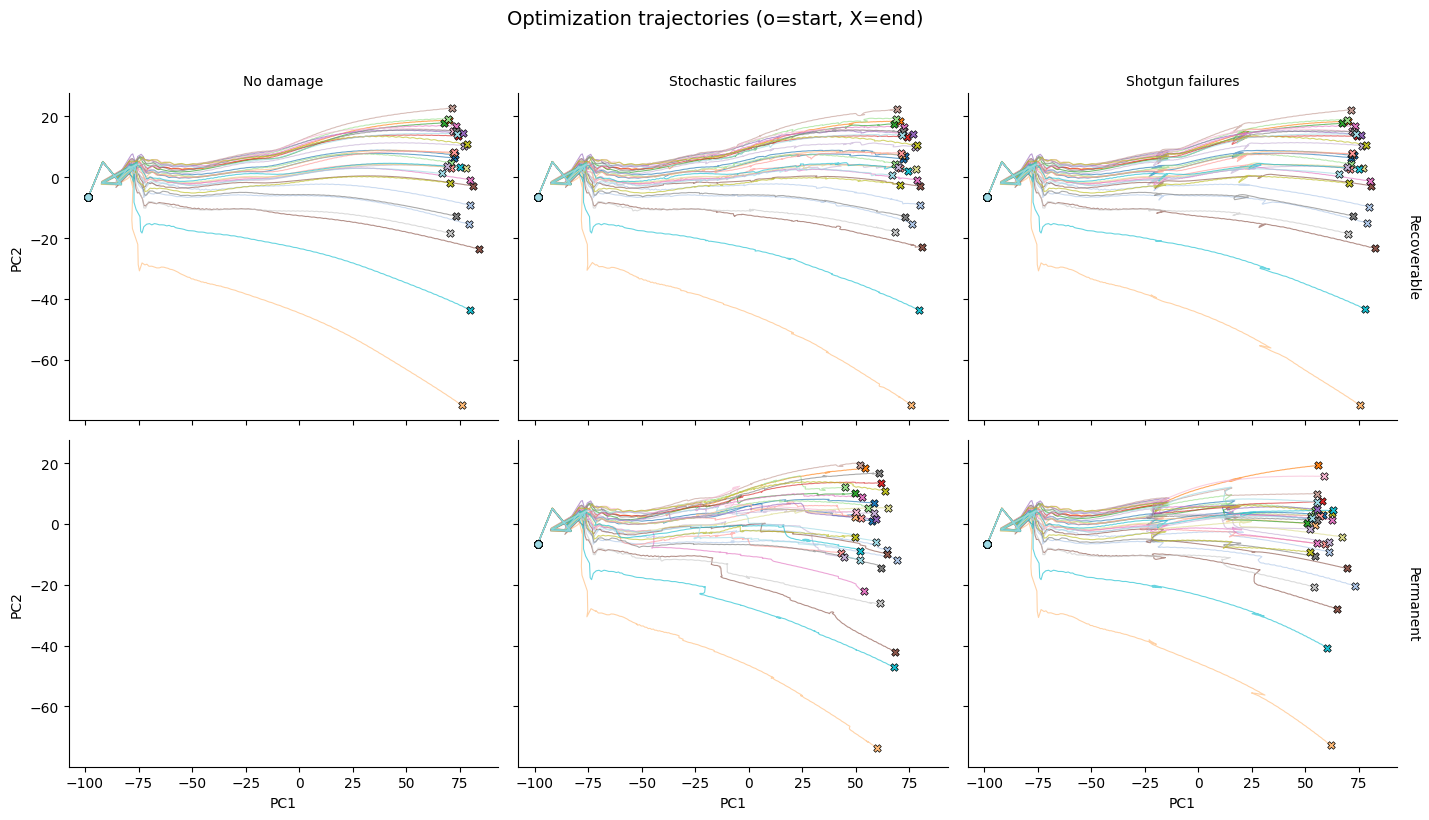

In [ ]:
# =====================================================================
# Trajectory LINES per batch, faceted by condition
# (seaborn FacetGrid + matplotlib line drawing)
# =====================================================================


def draw_trajectory_lines(data, x="PC1", y="PC2", **kwargs):
    """Map function for FacetGrid: draw one line per batch."""
    ax = plt.gca()
    color_map = plt.cm.get_cmap("tab20")
    batches = data["batch"].unique()
    models = data["model"].unique()
    linestyles = {"NCA": "-", "BP": "--"}

    for m in models:
        for b in batches:
            sub = data[(data["batch"] == b) & (data["model"] == m)].sort_values("step")
            c = color_map(b / max(batches.max(), 1))
            ax.plot(
                sub[x].values, sub[y].values, color=c, alpha=0.65, lw=0.8, linestyle=linestyles[m]
            )

            # Start marker
            ax.scatter(
                sub[x].iloc[0],
                sub[y].iloc[0],
                color=c,
                s=30,
                marker="o",
                edgecolors="k",
                linewidths=0.5,
                zorder=5,
            )
            # End marker
            ax.scatter(
                sub[x].iloc[-1],
                sub[y].iloc[-1],
                color=c,
                s=30,
                marker="X",
                edgecolors="k",
                linewidths=0.5,
                zorder=5,
            )


g = sns.FacetGrid(
    traj_df_pca,
    col="damage_label",
    row="permanent_label",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=4,
    aspect=1.2,
)
g.map_dataframe(draw_trajectory_lines)
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("PC1", "PC2")
g.figure.suptitle("Optimization trajectories (o=start, X=end)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## Scale-free experiments

In [287]:
case_n = 2**loaded_config.circuit.input_bits
base_key = jax.random.PRNGKey(loaded_config.seed)
eval_key = jax.random.fold_in(base_key, 1)
hidden_dim = loaded_config.circuit.circuit_hidden_dim
n_message_steps = loaded_config.training.n_message_steps
input_n, output_n = loaded_config.circuit.input_bits, loaded_config.circuit.output_bits
arity = loaded_config.circuit.arity


layer_widths = [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]

layer_sizes = {
    width_factor: generate_layer_sizes(
        input_n,
        output_n,
        arity,
        layer_n=loaded_config.circuit.num_layers,
        width_factor=width_factor,
    )
    for width_factor in layer_widths
}

if loaded_config.training.wiring_mode == "fixed":
    pool_key = eval_key
else:
    pool_key = jax.random.fold_in(eval_key, 1)

wires_key, logits_key = jax.random.split(pool_key, 2)

batch_size = 16

pools = {
    width_factor: initialize_graph_pool(
        wires_key=wires_key,
        logits_key=logits_key,
        pool_size=batch_size,
        layer_sizes=layer_sizes[width_factor],
        arity=arity,
        input_n=input_n,
        circuit_hidden_dim=hidden_dim,
        wiring_mode=loaded_config.training.wiring_mode,
        # noise_scale=loaded_config.pool.noise_scale,
        noise_scale=0.1,
    )
    for width_factor in layer_widths
}


In [288]:
# Load model from config and checkpoint
best_attn_models = {
    key: load_model_from_config_and_checkpoint(
        config=loaded_config,
        checkpoint_path=checkpoint_path,
        run_id=run_id,
        seed=loaded_config.seed,
        n_node=int(pool.graphs.n_node[0].item()),
    )[0]
    for key, pool in pools.items()
}


2026-02-10 21:43:13,062 - boolean_nca_cc.training.checkpointing - INFO - Loading model from saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-10 21:43:13,063 - boolean_nca_cc.training.checkpointing - INFO - Loading checkpoint with compatibility handling: saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-10 21:43:13,070 - boolean_nca_cc.training.checkpointing - INFO - Successfully loaded checkpoint with working compatibility loader
2026-02-10 21:43:13,070 - boolean_nca_cc.training.checkpointing - INFO - Converted compatible objects to nnx format
2026-02-10 21:43:13,089 - boolean_nca_cc.training.checkpointing - INFO - Loading model from saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-10 21:43:13,090 - boolean_nca_cc.training.checkpointing - INFO - Loading checkpoint with compatibility handling: saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-10 21:43:13,097 - boolean_nca_cc

2026-02-10 21:43:13,148 - boolean_nca_cc.training.checkpointing - INFO - Loading model from saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-10 21:43:13,149 - boolean_nca_cc.training.checkpointing - INFO - Loading checkpoint with compatibility handling: saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-10 21:43:13,154 - boolean_nca_cc.training.checkpointing - INFO - Successfully loaded checkpoint with working compatibility loader
2026-02-10 21:43:13,155 - boolean_nca_cc.training.checkpointing - INFO - Converted compatible objects to nnx format
2026-02-10 21:43:13,172 - boolean_nca_cc.training.checkpointing - INFO - Loading model from saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-10 21:43:13,173 - boolean_nca_cc.training.checkpointing - INFO - Loading checkpoint with compatibility handling: saves/run_f1vzpb58/best_model_eval_damaged_out_test_hard_accuracy.pkl
2026-02-10 21:43:13,179 - boolean_nca_cc

Instantiating model using config: boolean_nca_cc.models.CircuitGatheredAttention
Instantiate overrides: {'arity': 4, 'rngs': Rngs( # RngState: 2 (12 B)
  params=RngStream( # RngState: 2 (12 B)
    tag='params',
    key=RngKey( # 1 (8 B)
      value=Array((), dtype=key<fry>) overlaying:
      [0 0],
      tag='params'
    ),
    count=RngCount( # 1 (4 B)
      value=Array(0, dtype=uint32),
      tag='params'
    )
  )
), 'n_node': 168}
Successfully instantiated model: CircuitGatheredAttention
Instantiating model using config: boolean_nca_cc.models.CircuitGatheredAttention
Instantiate overrides: {'arity': 4, 'rngs': Rngs( # RngState: 2 (12 B)
  params=RngStream( # RngState: 2 (12 B)
    tag='params',
    key=RngKey( # 1 (8 B)
      value=Array((), dtype=key<fry>) overlaying:
      [0 0],
      tag='params'
    ),
    count=RngCount( # 1 (4 B)
      value=Array(0, dtype=uint32),
      tag='params'
    )
  )
), 'n_node': 216}
Successfully instantiated model: CircuitGatheredAttention
Instan

2026-02-10 21:43:13,273 - boolean_nca_cc.training.checkpointing - INFO - Successfully loaded checkpoint with working compatibility loader
2026-02-10 21:43:13,273 - boolean_nca_cc.training.checkpointing - INFO - Converted compatible objects to nnx format


Instantiating model using config: boolean_nca_cc.models.CircuitGatheredAttention
Instantiate overrides: {'arity': 4, 'rngs': Rngs( # RngState: 2 (12 B)
  params=RngStream( # RngState: 2 (12 B)
    tag='params',
    key=RngKey( # 1 (8 B)
      value=Array((), dtype=key<fry>) overlaying:
      [0 0],
      tag='params'
    ),
    count=RngCount( # 1 (4 B)
      value=Array(0, dtype=uint32),
      tag='params'
    )
  )
), 'n_node': 552}
Successfully instantiated model: CircuitGatheredAttention


In [289]:
attn_eval_results = {
    (key, damage): evaluate_model_stepwise_batched(
        model=best_attn_models[key],
        batch_wires=pools[key].wires,
        batch_logits=pools[key].logits,
        x_data=x_test,
        y_data=y_test,
        input_n=input_n,
        n_message_steps=256,
        arity=arity,
        circuit_hidden_dim=hidden_dim,
        loss_cfg=LossConfig(dict(loaded_config.loss)),
        layer_sizes=layer_sizes[key],
        damage_steps=None,
        knockout_per_damage_step=None,
        p_fault=damage_params["p_fault_eval"] * 2 if damage else None,
        bidirectional_edges=True,
        permanent_damage=True,
        verbose=True,
        # No-repair baseline
        compute_no_repair_baseline=False,
        p_fault_onset_step=0,
    )
    for key in pools
    for damage in [True, False]
}


Evaluation complete: 256 steps
  Loss: 5330.2412
  Accuracy: 0.6853
  Hard Acc: 0.6836
Evaluation complete: 256 steps
  Loss: 4019.6865
  Accuracy: 0.7648
  Hard Acc: 0.7641
Evaluation complete: 256 steps
  Loss: 4310.2803
  Accuracy: 0.7351
  Hard Acc: 0.7338
Evaluation complete: 256 steps
  Loss: 2863.7695
  Accuracy: 0.8312
  Hard Acc: 0.8312
Evaluation complete: 256 steps
  Loss: 3759.6614
  Accuracy: 0.8030
  Hard Acc: 0.8024
Evaluation complete: 256 steps
  Loss: 2004.8647
  Accuracy: 0.8865
  Hard Acc: 0.8866
Evaluation complete: 256 steps
  Loss: 3443.9553
  Accuracy: 0.8192
  Hard Acc: 0.8169
Evaluation complete: 256 steps
  Loss: 1498.9294
  Accuracy: 0.9136
  Hard Acc: 0.9137
Evaluation complete: 256 steps
  Loss: 3521.2358
  Accuracy: 0.8165
  Hard Acc: 0.8142
Evaluation complete: 256 steps
  Loss: 1653.4735
  Accuracy: 0.9060
  Hard Acc: 0.9061
Evaluation complete: 256 steps
  Loss: 2929.3228
  Accuracy: 0.8284
  Hard Acc: 0.8250
Evaluation complete: 256 steps
  Loss: 1373

In [292]:
all_results = []

for (width_factor, damage_active), results in attn_eval_results.items():
    final_graphs, step_metrics = results
    n_node = final_graphs.n_node[0].item()

    for batch_idx in range(batch_size):
        all_results.append(
            {
                "width_factor": width_factor,
                "n_node": n_node,
                "damage_active": damage_active,
                "batch_idx": batch_idx,
            }
        )

        for metric in ["hard_accuracy", "hard_loss", "accuracy", "loss"]:
            all_results[-1][metric] = step_metrics["all_metrics"][metric][batch_idx, -1].item()


In [293]:
scale_free_pd = pd.DataFrame(all_results)
scale_free_pd.head()

,width_factor,n_node,damage_active,batch_idx,hard_accuracy,hard_loss,accuracy,loss
0,1.0,168,True,0,0.605922,62056.902344,0.618437,5889.942383
1,1.0,168,True,1,0.703500,46786.238281,0.707061,4956.854004
2,1.0,168,True,2,0.601038,62881.171875,0.592287,7542.642578
3,1.0,168,True,3,0.833232,26289.468750,0.834147,2551.619141
4,1.0,168,True,4,0.632580,57894.742188,0.635531,5352.701660


In [300]:
scale_free_pd["dmg_config"] = scale_free_pd["damage_active"].map(
    {True: "Damages-ON", False: "Damages-OFF"}
)


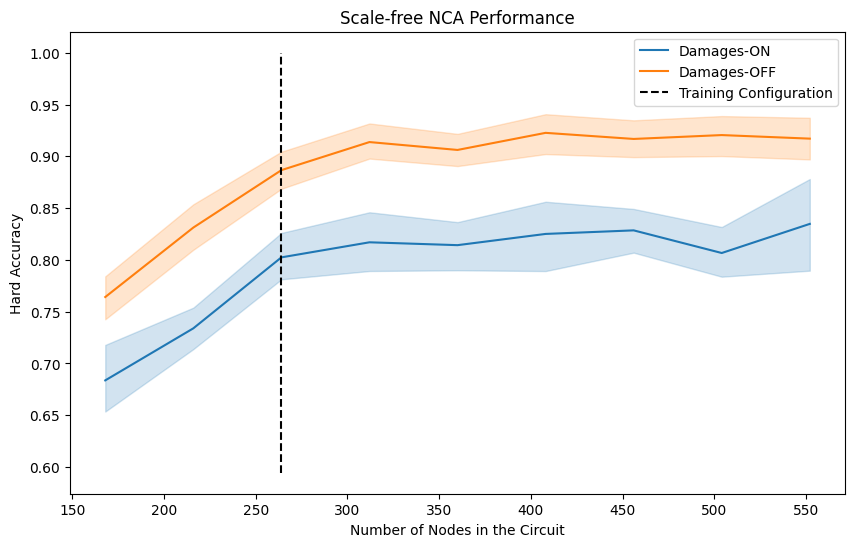

In [301]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=scale_free_pd,
    x="n_node",
    y="hard_accuracy",
    hue="dmg_config",
    ax=ax,
)

ax.vlines(
    264,
    scale_free_pd["hard_accuracy"].min(),
    scale_free_pd["hard_accuracy"].max(),
    color="k",
    linestyle="--",
    label="Training Configuration",
)
ax.legend()
ax.set_title("Scale-free NCA Performance")
ax.set_xlabel("Number of Nodes in the Circuit")
ax.set_ylabel("Hard Accuracy")
plt.show()
